In [1]:
import torch
import torch.nn as nn
from torch.nn import Sequential
from torch.nn import Linear
from torch.nn import Flatten
from torch.nn import BatchNorm1d
from torch.nn import Conv2d
from torch.nn import MaxPool2d
from torch.nn import BatchNorm2d
from torch.nn import ConvTranspose2d
from torch.nn import ReLU
from torch.nn import Sigmoid
from torch.nn import Dropout
from torch.nn import Softmax, Tanh
from torch.nn import Module
from torch.nn.init import kaiming_uniform_
from torch.nn.init import xavier_uniform_

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import re
from PIL import Image

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

import torch
from torch import Tensor
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.nn import MSELoss
from torch.nn import BCELoss, BCEWithLogitsLoss
from torch.optim import SGD, Adam, RMSprop 
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision.transforms import Compose
from torchvision.transforms import ToTensor
from torchvision.utils import save_image, make_grid
from xgboost import XGBClassifier

#pip install torchinfo
from torchinfo import summary
from livelossplot import PlotLosses

In [2]:
class VAE_CONV(Module):
    def __init__(self, final=True):
        super(VAE_CONV, self).__init__()
        # encoder
        self.conv1 = Conv2d(1,   32,  kernel_size=3, stride=2, padding=1)  # 32×128×128
        self.conv2 = Conv2d(32,  64,  kernel_size=3, stride=2, padding=1)  # 64×64×64
        self.conv3 = Conv2d(64,  128, kernel_size=3, stride=2, padding=1)  # 128×32×32
        self.conv4 = Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # 256×16×16
        self.conv5 = Conv2d(256, 256, kernel_size=3, stride=2, padding=1)  # 256×8×8
        self.fc_mu      = Linear(256 * 8 * 8, 256)
        self.fc_log_var = Linear(256 * 8 * 8, 256)
        # decoder — lighter channel budget, same spatial upsampling
        self.fc4    = Linear(256, 256 * 8 * 8)
        self.convT1 = ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 128×16×16
        self.convT2 = ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1)  # 64×32×32
        self.convT3 = ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1)  # 32×64×64
        self.convT4 = ConvTranspose2d(32,  16,  kernel_size=4, stride=2, padding=1)  # 16×128×128
        self.convT5 = ConvTranspose2d(16,  1,   kernel_size=4, stride=2, padding=1)  # 1×256×256

    def encoder(self, x):
        x = self.conv1(x).relu()
        x = self.conv2(x).relu()
        x = self.conv3(x).relu()
        x = self.conv4(x).relu()
        x = self.conv5(x).relu()
        x = torch.flatten(x, start_dim=1)
        mu      = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var

    def decoder(self, z):
        z = self.fc4(z).relu()
        z = z.view(-1, 256, 8, 8)
        z = self.convT1(z).relu()
        z = self.convT2(z).relu()
        z = self.convT3(z).relu()
        z = self.convT4(z).relu()
        z = self.convT5(z).sigmoid()
        return z

    def sampling(self, mu, log_var):
        std    = torch.exp(0.5 * log_var)
        eps    = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def forward(self, x, final=True):
        mu, log_var = self.encoder(x)
        sample      = self.sampling(mu, log_var)
        outputs     = self.decoder(sample)
        return outputs, mu, log_var, sample

In [3]:
#Constants

#path para guardar o dataset
PATH = './'
DATA_FOLDER = './data_images/MIQR-CC-Dataset/processed'
TEST_FOLDER = './dataset/test'

BATCH_SIZE = 128

In [4]:
#device management 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

device = get_default_device()
print(device)

cuda


In [5]:

class FolderDataset(Dataset):
    def __init__(self, data_folder, test_folder, img_size=256):

        # --- extract the image<n> keys from the test folder to exclude ---
        # test format:  <p>_<p>_image<n>_<optional_desc>.png
        # data format:      <p>_image<n>_<optional_desc>.png
        test_keys = set()
        for root, dirs, files in os.walk(test_folder):
            for fname in files:
                if not fname.lower().endswith('.png'):
                    continue
                match = re.search(r'(?:^|_)(image\d+)(?:_|\.|$)', fname, re.IGNORECASE)
                if match:
                    test_keys.add(match.group(1).lower())

        # --- collect all images from data_folder not in test_keys ---
        all_images, all_patients = [], []
        
        for fname in os.listdir(data_folder):
            if not fname.lower().endswith('.png'):
                continue
            match = re.search(r'(?:^|_)(image\d+)(?:_|\.|$)', fname, re.IGNORECASE)
            if match and match.group(1).lower() in test_keys:
                continue  # skip test images

            patient_id = fname.split('_image')[0]
            all_images.append(os.path.join(data_folder, fname))
            all_patients.append(patient_id)

        self.img_size = img_size

        # --- compute normalization range without storing all image tensors ---
        xmin, xmax = float('inf'), float('-inf')
        for path in all_images:
            img = Image.open(path).convert('L').resize((img_size, img_size))
            arr = np.array(img, dtype=np.float32)
            xmin = min(xmin, arr.min())
            xmax = max(xmax, arr.max())
        self.xmin = xmin
        self.denominator = max(1.0, xmax - xmin)

        patients = np.array(all_patients, dtype='<U')

        # --- train / test split by patient (80/20) ---
        patient_ids = np.unique(patients)
        np.random.shuffle(patient_ids)
        n_train_patients = max(1, int(0.8 * len(patient_ids)))
        train_patients = set(patient_ids[:n_train_patients])

        train_mask = np.array([patient in train_patients for patient in patients])

        self.train_files = [path for path, keep in zip(all_images, train_mask) if keep]
        self.test_files  = [path for path, keep in zip(all_images, train_mask) if not keep]

    def __len_train__(self):
        return len(self.train_files)

    def __len_test__(self):
        return len(self.test_files)

    def load_image(self, path):
        img = Image.open(path).convert('L').resize((self.img_size, self.img_size))
        arr = np.array(img, dtype=np.float32)
        arr = (arr - self.xmin) / self.denominator
        return torch.from_numpy(arr[np.newaxis, :, :])

    def __getitem_train__(self, idx):
        return self.load_image(self.train_files[idx])

    def __getitem_test__(self, idx):
        return self.load_image(self.test_files[idx])

    def get_splits(self):
        train = ImageFileDataset(self.train_files, self.img_size, self.xmin, self.denominator)
        test  = ImageFileDataset(self.test_files,  self.img_size, self.xmin, self.denominator)
        return train, test


class ImageFileDataset(Dataset):
    def __init__(self, files, img_size, xmin, denominator):
        self.files = files
        self.img_size = img_size
        self.xmin = xmin
        self.denominator = denominator

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert('L').resize((self.img_size, self.img_size))
        arr = np.array(img, dtype=np.float32)
        arr = (arr - self.xmin) / self.denominator
        arr = arr[np.newaxis, :, :]
        return torch.from_numpy(arr)


def prepare_data_flat(data_folder, test_folder):
    dataset = FolderDataset(data_folder, test_folder)
    train, test = dataset.get_splits()
    train_dl     = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
    test_dl      = DataLoader(test,  batch_size=BATCH_SIZE, shuffle=True)
    train_dl_all = DataLoader(train, batch_size=min(len(train), BATCH_SIZE), shuffle=False)
    test_dl_all  = DataLoader(test,  batch_size=min(len(test), BATCH_SIZE),  shuffle=False)
    return train_dl, test_dl, train_dl_all, test_dl_all


train_dl, test_dl, train_dl_all, test_dl_all = prepare_data_flat(DATA_FOLDER, TEST_FOLDER)

torch.Size([128, 1, 256, 256])


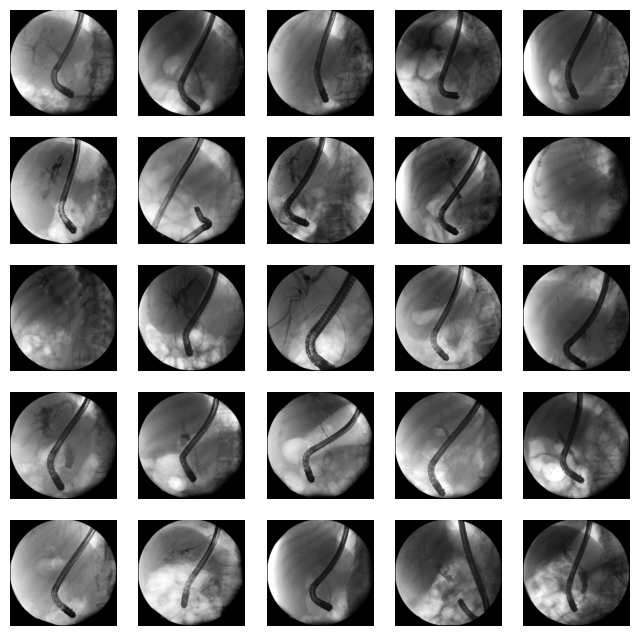

19041


In [6]:
def visualize_images(dl):
    # get one batch of images
    i, inputs = next(enumerate(dl))
    print(inputs.shape)
    # plot some images
    plt.figure(figsize=(8,8))
    for i in range(25):
        # define subplot
        plt.subplot(5, 5, i+1)
        plt.axis('off')
        plt.grid()
        # plot raw pixel data
        plt.imshow(inputs[i][0], cmap='gray')
    # show the figure
    plt.show()

visualize_images(train_dl)
print(len(train_dl.dataset)+len(test_dl.dataset))

In [7]:
model = VAE_CONV().to(device)
summary(model, input_size=(BATCH_SIZE, 1, 256, 256), verbose=0)

Layer (type:depth-idx)                   Output Shape              Param #
VAE_CONV                                 [128, 1, 256, 256]        --
├─Conv2d: 1-1                            [128, 32, 128, 128]       320
├─Conv2d: 1-2                            [128, 64, 64, 64]         18,496
├─Conv2d: 1-3                            [128, 128, 32, 32]        73,856
├─Conv2d: 1-4                            [128, 256, 16, 16]        295,168
├─Conv2d: 1-5                            [128, 256, 8, 8]          590,080
├─Linear: 1-6                            [128, 256]                4,194,560
├─Linear: 1-7                            [128, 256]                4,194,560
├─Linear: 1-8                            [128, 16384]              4,210,688
├─ConvTranspose2d: 1-9                   [128, 128, 16, 16]        524,416
├─ConvTranspose2d: 1-10                  [128, 64, 32, 32]         131,136
├─ConvTranspose2d: 1-11                  [128, 32, 64, 64]         32,800
├─ConvTranspose2d: 1-12        

In [8]:
def train_model(h5_file, train_dl, test_dl, model, loss_function, optimizer, scheduler, epochs):
    liveloss = PlotLosses()
    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0
        for inputs in train_dl:
            inputs = inputs.to(device)
            outputs, mu, log_var, _ = model(inputs)
            loss = loss_function(outputs, inputs, mu, log_var)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_dl.dataset)
        logs['loss'] = epoch_loss * 1000

        # Validation phase
        model.eval()
        running_loss = 0.0
        with torch.no_grad():                          # ← added
            for inputs in test_dl:
                inputs = inputs.to(device)
                outputs, mu, log_var, _ = model(inputs)
                loss = loss_function(outputs, inputs, mu, log_var)
                running_loss += loss.item()
        epoch_loss = running_loss / len(test_dl.dataset)
        logs['val_loss'] = epoch_loss * 1000
        scheduler.step(epoch_loss)
        epoch_lr = optimizer.param_groups[0]['lr']
        logs['val_lr'] = epoch_lr
        liveloss.update(logs)
        liveloss.send()
    torch.save(model, h5_file)

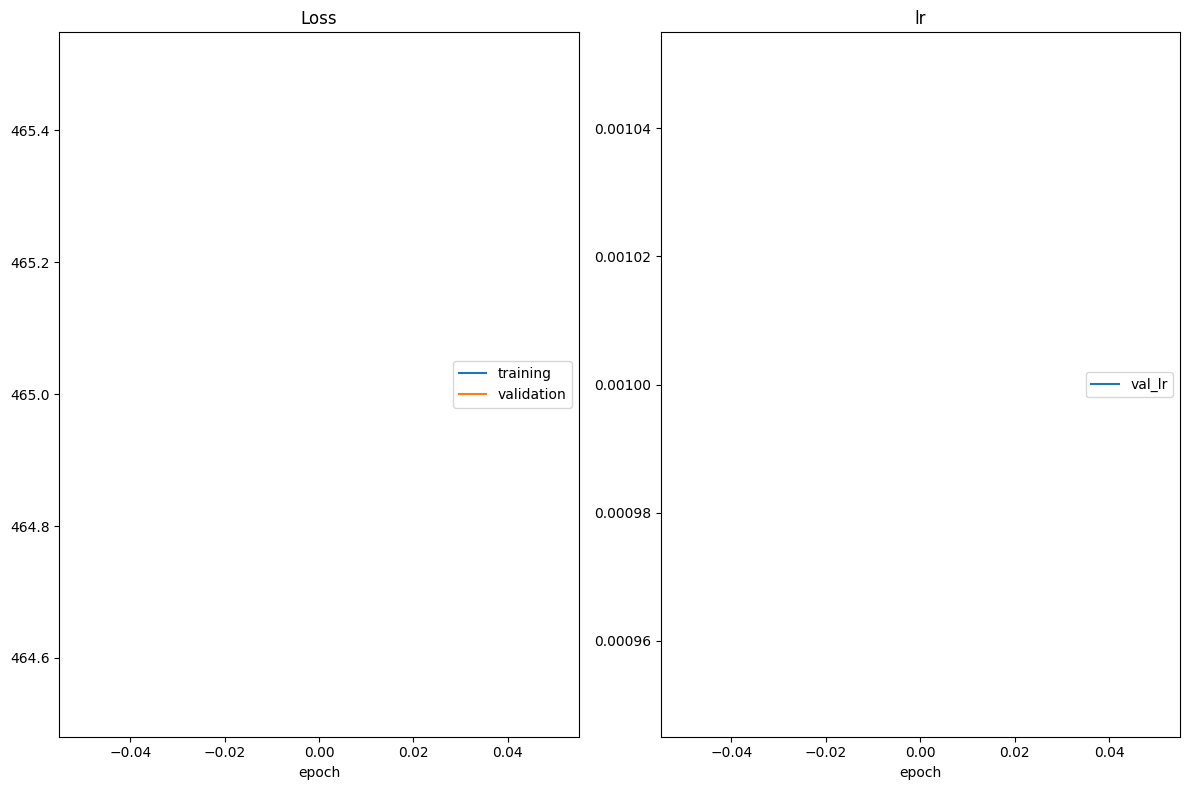

Loss
	training         	 (min:  464.529, max:  464.529, cur:  464.529)
	validation       	 (min:  465.500, max:  465.500, cur:  465.500)
lr
	val_lr           	 (min:    0.001, max:    0.001, cur:    0.001)
Tempo gasto: 4810.8103559 segundos


In [9]:
import torch.nn.functional as F

EPOCHS = 30
LEARNING_RATE = 0.001
KL_WEIGHT = 0.0          # anneals up to 1.0 over first 10 epochs
KL_ANNEAL_EPOCHS = 10    # how many epochs to ramp up over

def loss_function(recon_x, x, mu, log_var, kl_weight=1.0):
    n_pixels = x.size(1) * x.size(2) * x.size(3)   # 1×256×256 = 65 536
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / n_pixels
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / n_pixels
    return BCE + kl_weight * KLD

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5)

starttime = time.perf_counter()
for epoch in range(EPOCHS):
    kl_weight = min(1.0, (epoch + 1) / KL_ANNEAL_EPOCHS)
    train_model('VAE_CONV.pth', train_dl, test_dl, model,
                lambda r, x, mu, lv: loss_function(r, x, mu, lv, kl_weight),
                optimizer, scheduler, epochs=1)
endtime = time.perf_counter()
print(f"Tempo gasto: {endtime - starttime} segundos")

In [10]:
# Extract latent representation from the encoder for a given image tensor

def get_latent_representation(model, image_tensor):
    model.eval()
    with torch.no_grad():
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        image_tensor = image_tensor.to(device)
        mu, log_var = model.encoder(image_tensor)
        z = model.sampling(mu, log_var)
    return mu, log_var, z

# Example usage with one image from the test dataset
sample_image = next(iter(test_dl_all))[:1]
mu, log_var, z = get_latent_representation(model, sample_image)
print('mu shape:', mu.shape)
print('log_var shape:', log_var.shape)
print('sampled latent z shape:', z.shape)

mu shape: torch.Size([1, 256])
log_var shape: torch.Size([1, 256])
sampled latent z shape: torch.Size([1, 256])


In [11]:
# Train an XGBoost classifier on the latent image representations

# Use get_labels() from the notebook environment
X_train = mu.detach().cpu().numpy()
y_train = get_labels()

xgb_model = XGBClassifier(max_depth=2, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

print('XGBoost fit complete')
print('X_train shape:', X_train.shape)
print('y_train length:', len(y_train))

NameError: name 'get_labels' is not defined